In [4]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
import openpyxl
import seaborn as sb
# DATA LOADING 

df=pd.read_excel(r"C:\Data Analysis Internship\Project 2\Dataset for Data Analytics.xlsx")


In [18]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
# Checking how many rows and columns does dataset has 
df.shape 


(1200, 14)

In [ ]:
# Checking column name, value count and datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [ ]:
# Checking for null values

df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [22]:
df['CouponCode'] = df['CouponCode'].fillna('N/A')          #df.fillna({'CouponCode': 'N/A'}, inplace=True) - To change null values for multiple columns

In [16]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [ ]:
# Checking for duplicated values

df['CustomerID'].duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Name: CustomerID, Length: 1200, dtype: bool

In [54]:
print(" Descriptive Statistics -> ")
# df.describe()
metrics = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
valid_metrics = [m for m in metrics if m in df.columns]
print(df[valid_metrics].describe())

 Descriptive Statistics -> 
          Quantity    UnitPrice   TotalPrice  ItemsInCart
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750  1053.968300     5.485000
std       1.407557   197.177146   819.856558     2.281983
min       1.000000    11.390000    11.390000     1.000000
25%       2.000000   186.062500   410.520000     4.000000
50%       3.000000   364.210000   823.615000     5.000000
75%       4.000000   521.570000  1578.475000     7.000000
max       5.000000   699.930000  3456.400000    10.000000


In [66]:
# OUTLIERS INVESTIGATION (Using TotalPrice)

print("Outlier Detection (IQR Method) -> \n")
Q1 = df['TotalPrice'].quantile(0.25) # 25th Percentile 
Q3 = df['TotalPrice'].quantile(0.75) # 75th Percentile 
IQR = Q3 - Q1
        
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
        
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Normal Order Value Range: {max(0, lower_bound)} to {upper_bound}")
print(f"Flagged {len(outliers)} unusually high-value transaction outliers for investigation.")
print(f"\nOutliers Records -> \n{outliers}")
print("\n There are 8 records whose total order value is greater normal order values ")

Outlier Detection (IQR Method) -> 

Normal Order Value Range: 0 to 3330.4075
Flagged 8 unusually high-value transaction outliers for investigation.

Outliers Records -> 
        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card

In [64]:
# MAPPING CORRELATIONS

metrics = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
valid_metrics = [m for m in metrics if m in df.columns]
print(" Linear Relationship Strengths (Pearson r) -> \n")
if len(valid_metrics) > 1:
        print(df[valid_metrics].corr(method='pearson').round(2)) # Matrix of linear relationships
        print (""" \n Correlation	Meaning 
        +1.00	Perfect positive relationship 
        +0.80	Strong positive relationship 
        +0.50	Moderate positive relationship 
        0.00	No linear relationship 
        -0.50	Moderate negative relationship 
        -1.00	Perfect negative relationship""") 

 Linear Relationship Strengths (Pearson r) -> 

             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity         1.00       0.01        0.62         0.65
UnitPrice        0.01       1.00        0.72         0.00
TotalPrice       0.62       0.72        1.00         0.39
ItemsInCart      0.65       0.00        0.39         1.00
 
 Correlation	Meaning 
        +1.00	Perfect positive relationship 
        +0.80	Strong positive relationship 
        +0.50	Moderate positive relationship 
        0.00	No linear relationship 
        -0.50	Moderate negative relationship 
        -1.00	Perfect negative relationship



 Data Visualization -> 


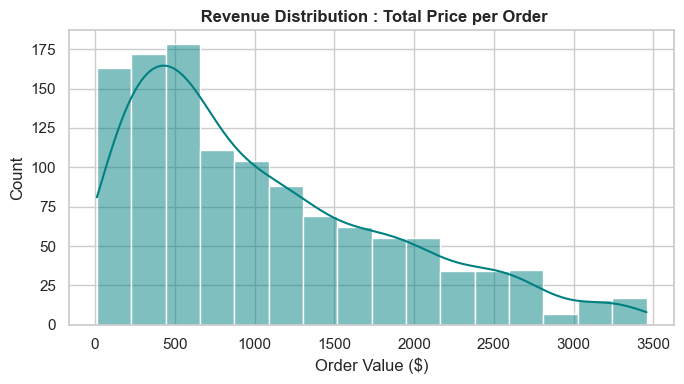

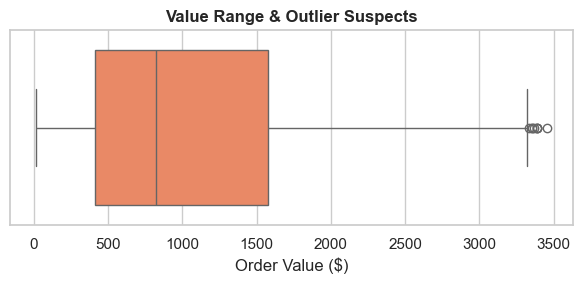

In [ ]:
# DESIGNING VISUAL EVIDENCE
    
print("\n Data Visualization -> ")
sb.set_theme(style="whitegrid") # Theme

# Chart 1 :  Distribution 
mp.figure(figsize=(7, 4))
sb.histplot(df['TotalPrice'], kde=True, color='teal')
mp.title('  Distribution : Total Price per Order', fontsize=12, fontweight='bold')
mp.xlabel('Order Value ($)')
mp.tight_layout()
mp.savefig('order_value_distribution.png')
mp.show()
mp.close()

# Chart 2: Boxplot for outliers 
mp.figure(figsize=(6, 3))
sb.boxplot(x=df['TotalPrice'], color='coral')
mp.title('Value Range & Outlier Suspects', fontsize=12, fontweight='bold')
mp.xlabel('Order Value ($)')
mp.tight_layout()
mp.savefig('order_value_boxplot.png')
mp.show()
mp.close()